## What is the most optimal skill to learn for Data Analysts?
##### Methodology
1. Continue from last notebook to find percent of postings with skill
2. Visualize median salary vs percent skill demand
3. Determine if certain technologies are more prevalent

#### Import Libraries and Data

In [1]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
df = pd.read_csv('/Users/briceverola/Desktop/Le Wagon/job_postings_flat.csv')

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

#### Clean Data

I filter the dataset to Data Analyst roles across selected European countries, remove missing salary values, and explode the skills column to analyze salary at the individual skill level.

In [53]:
countries = ['United Kingdom', 'Germany', 'France', 'Netherlands']

df_DA_FR = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'].isin(countries))].copy()

df_DA_FR = df_DA_FR.dropna(subset=['salary_year_avg'])

df_DA_FR_exploded = df_DA_FR.explode('job_skills')

df_DA_FR_exploded[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
4413,111202.0,sql
4413,111202.0,python
4413,111202.0,r
4413,111202.0,vba
4413,111202.0,pyspark


#### Calculate Skill Demand as a Percentage of Job Postings

I calculate how frequently each skill appears in Data Analyst job postings across Europe to measure its relative importance in the job market.

In [54]:
df_DA_skills = df_DA_FR_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)

df_DA_skills = df_DA_skills.rename(columns={'count': 'skill_count', 'median': 'median_salary'})

DA_job_count = len(df_DA_FR)  

df_DA_skills['skill_percent'] = df_DA_skills['skill_count'] / DA_job_count * 100

df_DA_skills = df_DA_skills[df_DA_skills['skill_count'] > 0]

df_DA_skills

,skill_count,median_salary,skill_percent
job_skills,,,
sql,133,89100.0,44.630872
python,104,89550.0,34.899329
excel,70,76975.0,23.489933
tableau,61,80850.0,20.469799
power bi,39,80850.0,13.087248
...,...,...,...
rust,1,56700.0,0.335570
ms access,1,105000.0,0.335570
cognos,1,89204.0,0.335570


#### Filter High-Demand Skills

I focus on the most relevant skills by keeping only those that appear in a significant share of Data Analyst job postings across Europe.

In [55]:
skill_limit = 5

df_DA_skills_high_demand = df_DA_skills[df_DA_skills['skill_percent'] > skill_limit]

I visualize the relationship between skill demand and salary to identify the most valuable skills for Data Analysts across Europe.

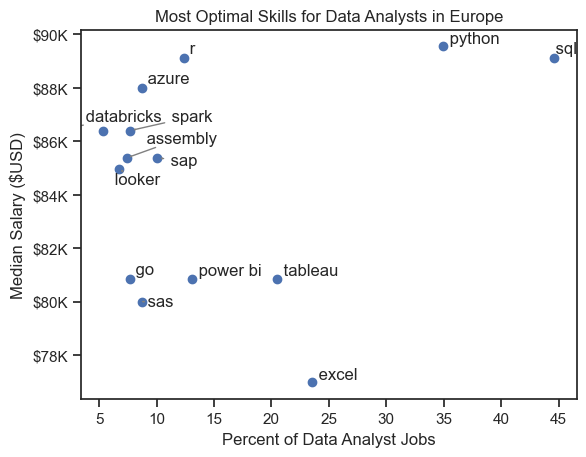

In [ ]:
from adjustText import adjust_text

plt.scatter(df_DA_skills_high_demand['skill_percent'], df_DA_skills_high_demand['median_salary'])
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Salary ($USD)')  
plt.title('Most Optimal Skills for Data Analysts in Europe')

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))  

texts = []
for i, txt in enumerate(df_DA_skills_high_demand.index):
    x = df_DA_skills_high_demand['skill_percent'].iloc[i]
    y = df_DA_skills_high_demand['median_salary'].iloc[i]
    
    if txt == 'databricks':
        x = x - 3.96  

    texts.append(plt.text(x, y, " " + txt))
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

plt.show()

### Categorize Skills by Technology

To enhance the analysis, I group skills into broader technology categories, allowing for clearer interpretation of patterns across different types of tools.

In [62]:
import ast

# Prepare technology mapping from dataset
df_technology = df['job_type_skills'].drop_duplicates().dropna()

technology_dict = {}

# Build dictionary of skills grouped by technology
for row in df_technology:
    row_dict = ast.literal_eval(row)
    for key, value in row_dict.items():
        if key in technology_dict:
            technology_dict[key] += value
        else:
            technology_dict[key] = value

# Ensure unique values for each category
for key in technology_dict:
    technology_dict[key] = list(set(technology_dict[key]))

technology_dict

{'analyst_tools': ['looker',
  'powerbi',
  'tableau',
  'power bi',
  'dax',
  'sheets',
  'microstrategy',
  'visio',
  'qlik',
  'esquisse',
  'cognos',
  'ms access',
  'spreadsheet',
  'sap',
  'ssrs',
  'sas',
  'splunk',
  'msaccess',
  'outlook',
  'datarobot',
  'spss',
  'nuix',
  'word',
  'excel',
  'ssis',
  'sharepoint',
  'alteryx',
  'powerpoint'],
 'async': ['smartsheet',
  'asana',
  'workzone',
  'swit',
  'airtable',
  'confluence',
  'wrike',
  'clickup',
  'workfront',
  'dingtalk',
  'microsoft lists',
  'wimi',
  'planner',
  'monday.com',
  'notion',
  'jira',
  'trello'],
 'cloud': ['openstack',
  'aurora',
  'bigquery',
  'ibm cloud',
  'redshift',
  'oracle',
  'vmware',
  'ovh',
  'heroku',
  'databricks',
  'linode',
  'aws',
  'gcp',
  'colocation',
  'azure',
  'watson',
  'digitalocean',
  'firebase',
  'snowflake'],
 'programming': ['fortran',
  'perl',
  'f#',
  'vb.net',
  'cobol',
  'c',
  'lisp',
  't-sql',
  'objective-c',
  'apl',
  'sass',
  'da

I transform the technology dictionary into a structured format to map each skill to its corresponding category for further analysis.

In [ ]:
# Convert technology dictionary into a structured DataFrame
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])

df_technology = df_technology.explode('skills')

df_technology

,technology,skills
0,analyst_tools,looker
0,analyst_tools,powerbi
0,analyst_tools,tableau
0,analyst_tools,power bi
0,analyst_tools,dax
...,...,...
9,sync,slack
9,sync,google chat
9,sync,twilio
9,sync,microsoft teams


I merge skill data with their corresponding technology categories to enrich the analysis and enable grouping by technology.

In [ ]:
df_DA_skills_tech = df_DA_skills.merge(df_technology, left_on='job_skills', right_on='skills')

df_DA_skills_tech

,skill_count,median_salary,skill_percent,technology,skills
0,133,89100.0,44.630872,programming,sql
1,104,89550.0,34.899329,programming,python
2,70,76975.0,23.489933,analyst_tools,excel
3,61,80850.0,20.469799,analyst_tools,tableau
4,39,80850.0,13.087248,analyst_tools,power bi
...,...,...,...,...,...
100,1,56700.0,0.335570,programming,rust
101,1,105000.0,0.335570,analyst_tools,ms access
102,1,89204.0,0.335570,analyst_tools,cognos
103,1,90600.0,0.335570,libraries,ggplot2


I focus on the most relevant skills by filtering for those with significant demand across Data Analyst job postings in Europe.

In [60]:
df_DA_skills_tech_high_demand = df_DA_skills_tech[df_DA_skills_tech['skill_percent'] > skill_limit]

I visualize the relationship between skill demand and salary, using colors to distinguish technology categories and better understand patterns across different types of skills.

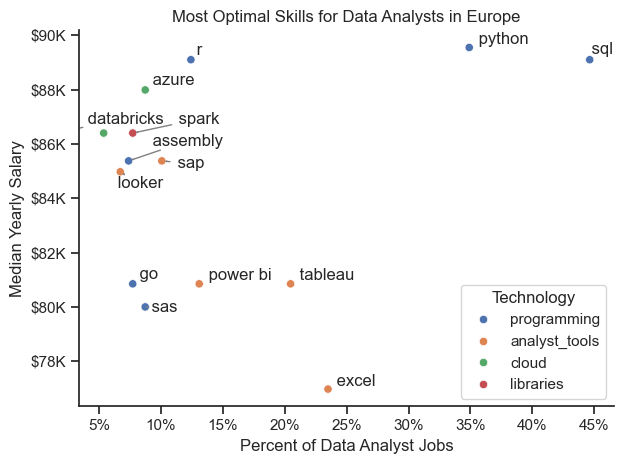

In [63]:
sns.scatterplot(
    data=df_DA_skills_tech_high_demand,
    x='skill_percent',
    y='median_salary',
    hue='technology'
)

sns.despine()
sns.set_theme(style='ticks')

# Prepare texts for adjustText
texts = []
for i, txt in enumerate(df_DA_skills_high_demand.index):
    x = df_DA_skills_high_demand['skill_percent'].iloc[i]
    y = df_DA_skills_high_demand['median_salary'].iloc[i]
    
    # 👉 déplacer uniquement databricks vers la gauche
    if txt == 'databricks':
        x = x - 3.96   # ajuste si besoin (-1.5 / -3 etc)
    
    texts.append(plt.text(x, y, " " + txt))

# Adjust text to avoid overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

# Set axis labels, title, and legend
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Analysts in Europe')
plt.legend(title='Technology')

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

# Adjust layout and display plot 
plt.tight_layout()
plt.show()